# Prior vs UCB in Gaussian Processes Regression

**Notation**: Given are GPs with mean function $\mu(x)$, covariance function $k(x, x')$ and data $D = \{x_i\}_{i=1}^n$ and $\mathbf{y}_D = \{y_i\}_{i=1}^n$. The covariance function is also written as 

$$
\mathbf{k}(x, D) = \begin{bmatrix}k(x, x_1) \\
\vdots \\
k(x, x_n)\end{bmatrix} \quad \text{and} \quad K(D, D) = \begin{bmatrix}k(x_1, x_1) & \cdots & k(x_1, x_n) \\
\vdots & \ddots & \vdots \\
k(x_n, x_1) & \cdots & k(x_n, x_n)\end{bmatrix}.
$$

Setting a high mean and doing a “greedy” highest-expectation search, i.e. $\max_x \mu'_p(x\mid \mu=\mu_0)$, is closely related to maximizing a UCB-style acquisition $\max_x \mu'(x\mid \mu\equiv 0)+\beta\,\sigma'^2(x)$ in the GP setting.

Using the notation from above, the GP posterior mean for a mean function $\mu$ is
$$
\mu'(x\mid \mu)=\mu(x)+\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\bigl(\mathbf{y}_D-\mu(D)\bigr),
$$
and the posterior variance (independent of $\mu$) is
$$
\sigma'^2(x)=k(x,x)-\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mathbf{k}(x,D).
$$

So the UCB acquisition with zero mean and confidence parameter $\beta$ can be written as
$$
\mu'(x\mid \mu = 0)+\beta\,\sigma'^2(x)
=\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mathbf{y}_D
\;\; +\beta\,k(x,x)-\beta\,\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mathbf{k}(x,D).
$$

Whereas the posterior mean under a nonzero mean $\mu_0$ can be written as
$$
\mu'_p(x\mid \mu=\mu_0)
=\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mathbf{y}_D
\;\; +\mu_0(x)-\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mu_0(D).
$$

Comparing the last terms suggests the heuristic identification
$$
\mu_0(x)\approx \beta\,k(x,x)
\quad\text{and}\quad
\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mathbf{k}(x,D)
\approx \mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\operatorname{diag}\bigl(K(D,D)\bigr),
$$
i.e. setting $\mu_0(x_i)=\beta\,k(x_i,x_i)$ on the observed inputs makes “greedy” maximization under $\mu_0$ behave similarly to UCB.

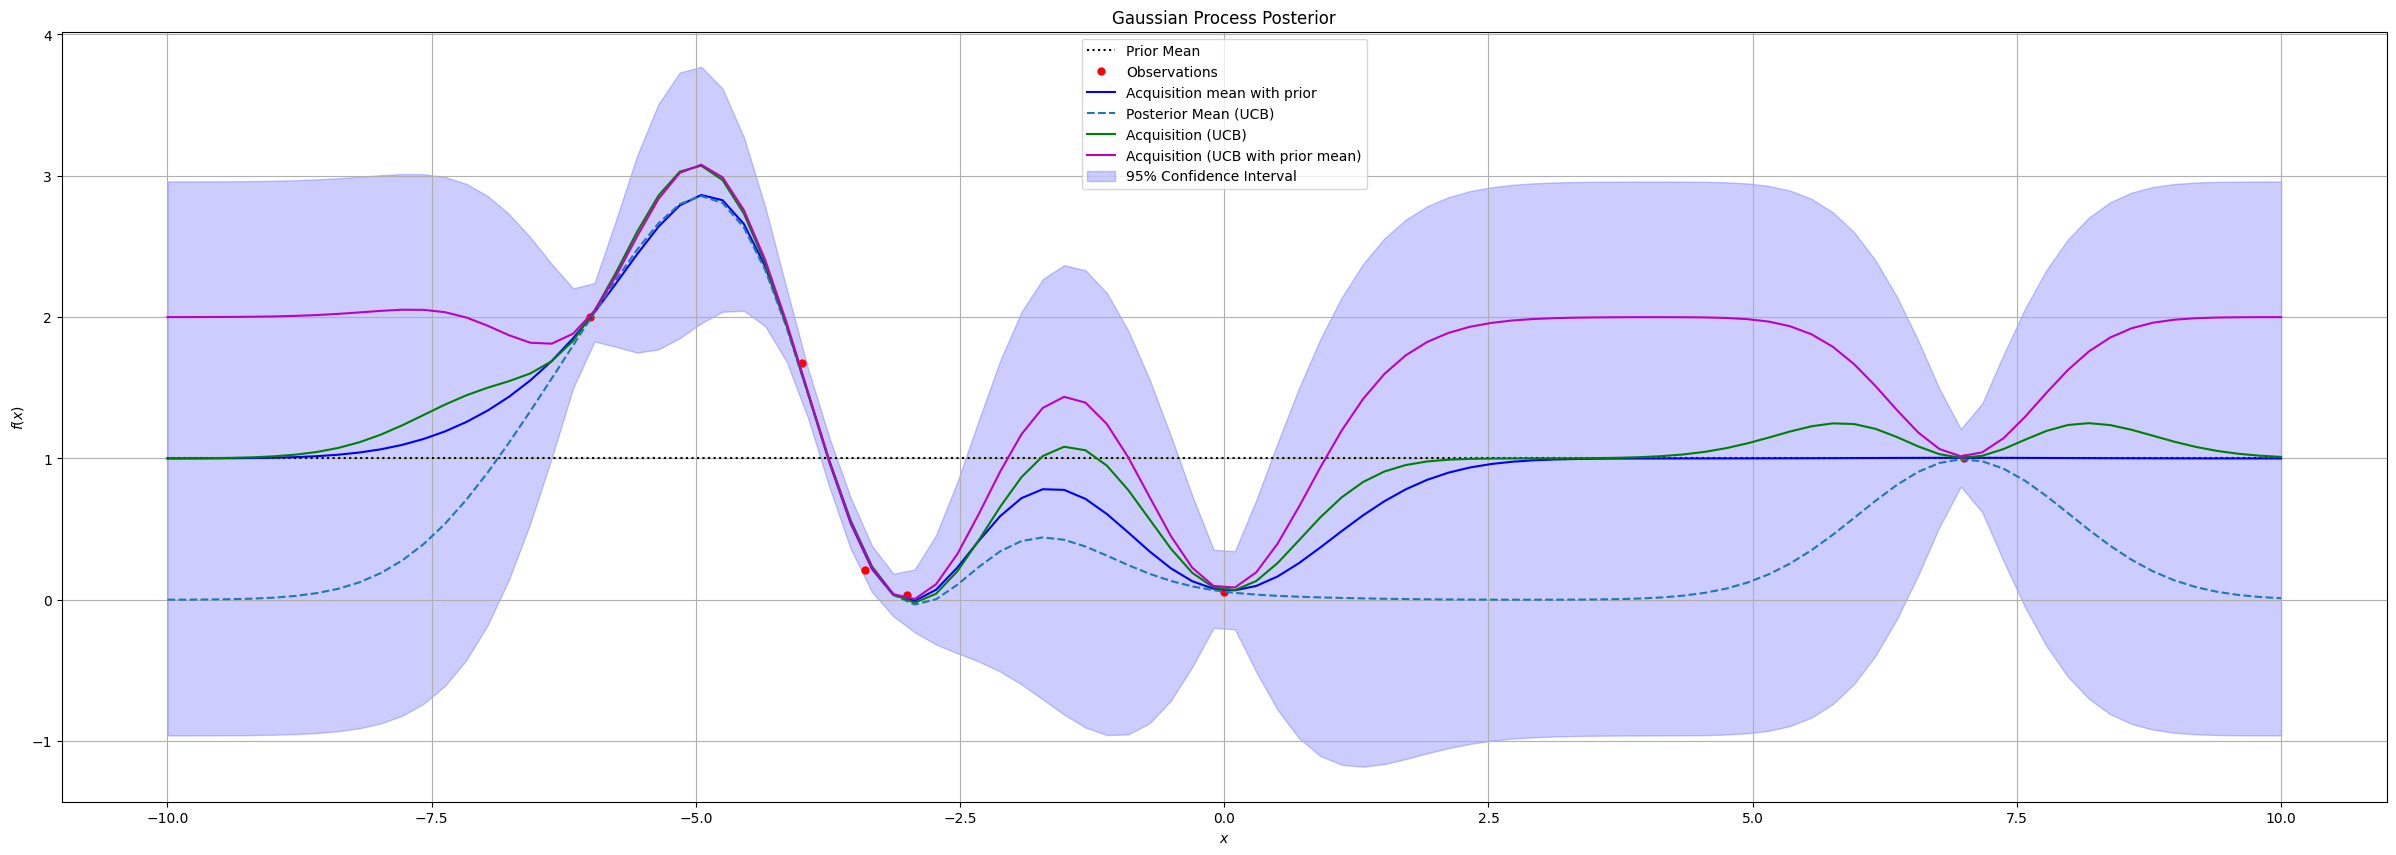

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Custom RBF Kernel implementation
class RBF:
    def __init__(self, length_scale=1.0, length_scale_bounds="fixed"):
        self.length_scale = length_scale
        self.length_scale_bounds = length_scale_bounds
    
    def __call__(self, X1, X2):
        """Compute the RBF kernel between X1 and X2"""
        # Compute squared Euclidean distance between each pair of points
        X1 = np.atleast_2d(X1)
        X2 = np.atleast_2d(X2)
        
        # Calculate distance matrix
        dists = np.sum(X1**2, axis=1)[:, np.newaxis] + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
        
        # Apply RBF kernel formula: K(x,y) = exp(-||x-y||^2 / (2*l^2))
        return np.exp(-dists / (2 * self.length_scale**2))

# Gaussian Process Regressor implementation
class GaussianProcessRegressor:
    def __init__(self, mean=None, kernel=None, alpha=1e-10, n_restarts_optimizer=0):
        self.mean = mean
        self.kernel = kernel if kernel is not None else RBF()
        self.alpha = alpha  # Noise level
        self.X_train = None
        self.y_train = None
        self.K_inv = None
        self.n_restarts_optimizer = n_restarts_optimizer

    def fit(self, X, y):
        """Fit Gaussian Process Regression model"""
        self.X_train = np.atleast_2d(X)
        self.y_train = np.atleast_1d(y)

        # Compute kernel matrix
        K = self.kernel(self.X_train, self.X_train)

        # Add noise to diagonal
        K_noisy = K + self.alpha * np.eye(len(self.X_train))

        # Compute inverse of kernel matrix
        self.K_inv = np.linalg.inv(K_noisy)
        return self

    def predict(self, X, return_std=False):
        """Predict using the Gaussian Process model"""
        X = np.atleast_2d(X)

        # Compute covariance between training and test points
        K_trans = self.kernel(X, self.X_train)

        # Compute mean prediction
        mean_X = self.mean(X) if self.mean is not None else np.zeros(X.shape[0])
        mean_train = self.mean(self.X_train) if self.mean is not None else np.zeros_like(self.y_train)
        y_mean = K_trans @ self.K_inv @ (self.y_train - mean_train) + mean_X

        if not return_std:
            return y_mean

        # Compute variance/standard deviation if requested
        K_test = self.kernel(X, X)
        y_var = K_test - K_trans @ self.K_inv @ K_trans.T
        # Extract diagonal elements for point-wise variances
        y_var = np.diag(y_var)
        y_var = np.maximum(y_var, 0)  # Ensure positive variance

        return y_mean, np.sqrt(y_var)

# --- Configuration ---
# Prior mean function (can be any callable)
def prior_mean_func(x):
    return np.ones(len(x))

# Define kernel
kernel = RBF(length_scale=1.0, length_scale_bounds="fixed")

# Observations
X_obs = np.array([-4, -3.4, -3, 0, 7, -6]).reshape(-1, 1)
y_obs = np.array([1.67268999, 0.20988119, 0.03688849, 0.05757694, 1.00456709, 2.])

# Observation noise level (added to the diagonal of the kernel matrix)
noise_level = 1e-1

# Points for prediction and plotting
X_plot = np.linspace(-10, 10, 100).reshape(-1, 1)
# ---

# Create and fit the Gaussian Process Regressor
prior_gp = GaussianProcessRegressor(mean=prior_mean_func, kernel=kernel, alpha=noise_level**2)
# Ensure y is 1D for fitting
prior_gp.fit(X_obs, y_obs) # Fit on data centered around prior

ucb_gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_level**2)
ucb_gp.fit(X_obs, y_obs)

# Make predictions
# Predictions and std deviation will now be 1D
y_pred, sigma = prior_gp.predict(X_plot, return_std=True)
y_mean_ucb, sigma_ucb = ucb_gp.predict(X_plot, return_std=True)

beta = 1.0
y_pred_ucb = y_mean_ucb + beta * sigma_ucb ** 2
y_pred_ucb_prior = y_pred + beta * sigma ** 2

# --- Visualization ---
plt.figure(figsize=(30, 10))

# Plot Prior Mean
plt.plot(X_plot, prior_mean_func(X_plot).ravel(), 'k:', label='Prior Mean')

# Plot Observations
plt.plot(X_obs, y_obs, 'r.', markersize=10, label='Observations')

# Plot Posterior Mean
plt.plot(X_plot, y_pred, "b-", label="Acquisition mean with prior")
plt.plot(X_plot, y_mean_ucb, "--", label="Posterior Mean (UCB)")
plt.plot(X_plot, y_pred_ucb, 'g-', label='Acquisition (UCB)')
plt.plot(X_plot, y_pred_ucb_prior, 'm-', label='Acquisition (UCB with prior mean)')

# Plot Confidence Interval
plt.fill_between(X_plot.ravel(), y_pred - 1.96 * sigma, y_pred + 1.96 * sigma,
                 alpha=0.2, color='blue', label='95% Confidence Interval')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Gaussian Process Posterior')
plt.legend()
plt.grid(True)
plt.show()